In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [12]:
data_path = Path("household_power_consumption.txt")

df = pd.read_csv(data_path, sep=";", na_values="?", low_memory=False)

df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)

df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")

df = df.dropna(subset=["Global_active_power"])
df = df.set_index("datetime").sort_index()

df_hourly = df[["Global_active_power"]].resample("h").mean().dropna()

df_hourly["hour"] = df_hourly.index.hour
df_hourly["day_of_week"] = df_hourly.index.dayofweek
df_hourly["day_of_year"] = df_hourly.index.dayofyear

target_col = "Global_active_power"

print(df_hourly.columns)
print(df_hourly.shape)
df_hourly.head()

Index(['Global_active_power', 'hour', 'day_of_week', 'day_of_year'], dtype='object')
(34168, 4)


,Global_active_power,hour,day_of_week,day_of_year
datetime,,,,
2006-12-16 17:00:00,4.222889,17,5,350
2006-12-16 18:00:00,3.632200,18,5,350
2006-12-16 19:00:00,3.400233,19,5,350
2006-12-16 20:00:00,3.268567,20,5,350
2006-12-16 21:00:00,3.056467,21,5,350


In [13]:
target_col = "Global_active_power"
fig_dir = Path("../figures")
fig_dir.mkdir(parents=True, exist_ok=True)

In [14]:
# feature functions

def fourier_features(df, K_hour=5, K_week=3, K_year=3):
    """
    Create Fourier features for hour of day, day of week, and day of year.
    Uses the same idea as in the main linear model notebook.
    """
    X = pd.DataFrame(index=df.index)

    hour = df["hour"].values if "hour" in df.columns else df.index.hour
    day_of_week = df["day_of_week"].values if "day_of_week" in df.columns else df.index.dayofweek
    day_of_year = df["day_of_year"].values if "day_of_year" in df.columns else df.index.dayofyear

    for k in range(1, K_hour + 1):
        X[f"hour_sin_{k}"] = np.sin(2 * np.pi * k * hour / 24)
        X[f"hour_cos_{k}"] = np.cos(2 * np.pi * k * hour / 24)

    for k in range(1, K_week + 1):
        X[f"week_sin_{k}"] = np.sin(2 * np.pi * k * day_of_week / 7)
        X[f"week_cos_{k}"] = np.cos(2 * np.pi * k * day_of_week / 7)

    for k in range(1, K_year + 1):
        X[f"year_sin_{k}"] = np.sin(2 * np.pi * k * day_of_year / 365)
        X[f"year_cos_{k}"] = np.cos(2 * np.pi * k * day_of_year / 365)

    return X


def add_autoregressive_features(df, target_col="Global_active_power"):
    """Add lagged load features for the AR experiment"""
    data = df.copy()
    y = data[target_col]

    # Direct lag features
    data["lag_1h"] = y.shift(1)
    data["lag_24h"] = y.shift(24)
    data["lag_168h"] = y.shift(168)   # same hour one week ago

    # Past rolling averages
    data["rolling_mean_24h"] = y.shift(1).rolling(window=24).mean()
    data["rolling_mean_168h"] = y.shift(1).rolling(window=168).mean()

    return data.dropna()


def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae


In [15]:
# build feature matrix for autoregressive model

df_ar = add_autoregressive_features(df_hourly, target_col=target_col)

y = df_ar[target_col]

X_fourier = fourier_features(
    df_ar,
    K_hour=5,
    K_week=3,
    K_year=3
)

ar_cols = [
    "lag_1h",
    "lag_24h",
    "lag_168h",
    "rolling_mean_24h",
    "rolling_mean_168h"
]

X_ar = df_ar[ar_cols]

X_combined = pd.concat([X_fourier, X_ar], axis=1)


In [16]:

split_idx = int(len(df_ar) * 0.8)

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

models_to_compare = {
    "Fourier only": X_fourier,
    "AR only": X_ar,
    "Fourier + AR": X_combined
}

In [17]:
# Train and evaluate Ridge models

results = []
predictions = {}

for name, X in models_to_compare.items():
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse, mae = evaluate_model(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae
    })

    predictions[name] = y_pred


results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

,Model,RMSE,MAE
2,Fourier + AR,0.504881,0.363453
1,AR only,0.523476,0.372663
0,Fourier only,0.639571,0.489831


The autoregressive features improve the test error. The AR-only Ridge model already performs better than the Fourier-only model. 
The best result is obtained by combining Fourier features with lagged consumption values. 
This suggests that recent electricity usage contains information that calendar time alone does not capture.

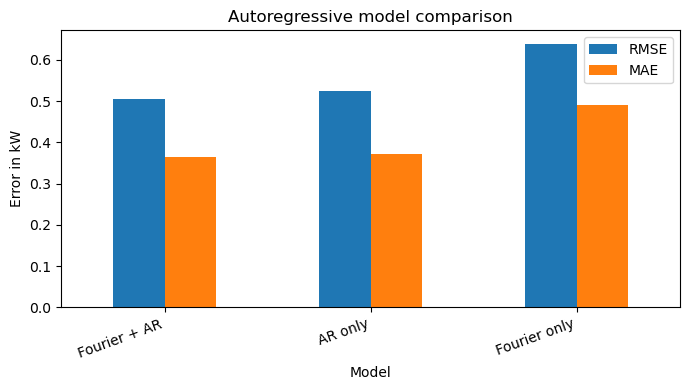

In [18]:
# Visualization of results

results_plot = results_df.set_index("Model")[["RMSE", "MAE"]]
results_plot.plot(kind="bar", figsize=(7, 4))

plt.ylabel("Error in kW")
plt.title("Autoregressive model comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(fig_dir / "ar_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

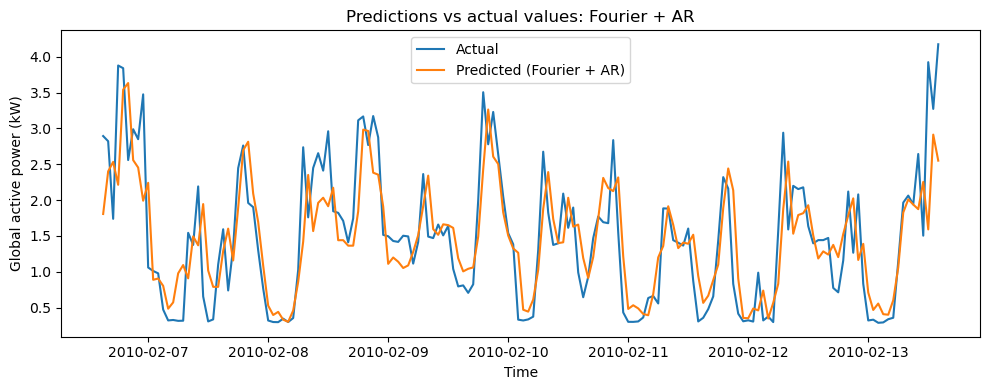

In [19]:
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]

n_plot = 24 * 7   # first week of test set

plt.figure(figsize=(10, 4))
plt.plot(y_test.index[:n_plot], y_test.iloc[:n_plot], label="Actual")
plt.plot(y_test.index[:n_plot], best_pred[:n_plot], label=f"Predicted ({best_model_name})")

plt.xlabel("Time")
plt.ylabel("Global active power (kW)")
plt.title(f"Predictions vs actual values: {best_model_name}")
plt.legend()
plt.tight_layout()

plt.savefig(fig_dir / "ar_predictions_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

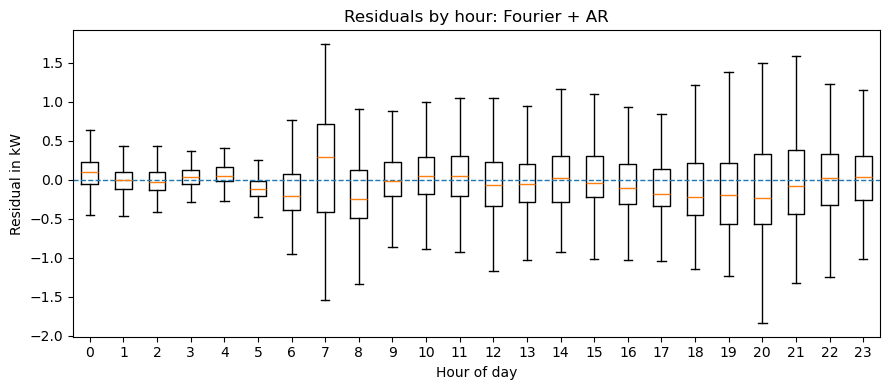

In [20]:
residuals = y_test.values - best_pred

residual_df = pd.DataFrame({
    "residual": residuals,
    "hour": y_test.index.hour
}, index=y_test.index)

groups = [
    residual_df.loc[residual_df["hour"] == h, "residual"]
    for h in range(24)
]

plt.figure(figsize=(9, 4))
plt.boxplot(groups, positions=range(24), showfliers=False)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Hour of day")
plt.ylabel("Residual in kW")
plt.title(f"Residuals by hour: {best_model_name}")
plt.xticks(range(24))
plt.tight_layout()

plt.savefig(fig_dir / "ar_residuals_by_hour.png", dpi=300, bbox_inches="tight")
plt.show()